In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../outputs")

holdout_features = pd.read_parquet(
    OUTPUT_DIR / "holdout_features.parquet"
)

graph_result = pd.read_csv(
    OUTPUT_DIR / "anomaly_graph_score.csv"
)

assert holdout_features["CustomerID"].is_unique
assert graph_result["CustomerID"].is_unique

holdout_features.shape, graph_result.shape

((20000, 119), (20000, 11))

In [2]:
def is_binary_series(s: pd.Series) -> bool:
    values = set(s.dropna().unique())
    return values.issubset({0, 1, 0.0, 1.0})


def percentile_risk(
    df: pd.DataFrame,
    col: str,
    high_is_risk: bool = True,
) -> pd.Series:
    """
    Chuyển 1 feature về risk score [0, 1]

    high_is_risk=True:
        large value = risky

    high_is_risk=False:
        large value = trustworthy/safe
    """
    s = pd.to_numeric(df[col], errors="coerce")

    if s.isna().all():
        return pd.Series(0.0, index=df.index)

    # Median imputation
    s = s.fillna(s.median())

    # Cứ 1 là rủi ro cao nhất, 0 là an toàn nhất
    if is_binary_series(s):
        risk = s.astype(float) if high_is_risk else 1.0 - s.astype(float)
        return risk.clip(0, 1)

    # Nếu tất cả giá trị đều bẳng nhau, không có risk signal
    if s.nunique(dropna=True) <= 1:
        return pd.Series(0.0, index=df.index)

    pct = s.rank(method="average", pct=True)

    risk = pct if high_is_risk else 1.0 - pct

    return risk.clip(0, 1)


def weighted_mean_risk(
    df: pd.DataFrame,
    specs: list[tuple[str, bool, float]],
    prefix: str,
) -> tuple[pd.Series, pd.DataFrame]:
    """
    specs = [(feature_name, high_is_risk, weight), ...]
    """
    component_df = pd.DataFrame(index=df.index)
    weighted_sum = pd.Series(0.0, index=df.index)
    total_weight = 0.0

    for col, high_is_risk, weight in specs:
        if col not in df.columns:
            continue

        risk = percentile_risk(
            df=df,
            col=col,
            high_is_risk=high_is_risk,
        )

        component_name = f"{prefix}_{col}_risk"
        component_df[component_name] = risk

        weighted_sum += weight * risk
        total_weight += weight

    if total_weight == 0:
        pillar_risk = pd.Series(0.0, index=df.index)
    else:
        pillar_risk = weighted_sum / total_weight

    return pillar_risk.clip(0, 1), component_df

In [3]:
STRONG = 1.5
MEDIUM = 1.0
WEAK = 0.5
CONTEXT = 0.25
OBSERVATION_ONLY = 0.0


# 1. Device Integrity
# high_is_risk=True means larger value is riskier.
# high_is_risk=False means larger value is safer.

device_specs = [
    # Direct device compromise / automation signals
    ("is_emulator", True, STRONG),
    ("emulator_session_ratio", True, STRONG),
    ("is_generic_or_clone", True, STRONG),
    ("tac_grey_clone_flag", True, STRONG),

    # Device-type context: feature phones are not emulator risk by themselves.
    ("is_feature_phone", True, OBSERVATION_ONLY),

    # Rooted/jailbroken device signals
    ("is_rooted", True, MEDIUM),
    ("rooted_session_ratio", True, MEDIUM),

    # Device reputation / TAC-level risk
    ("tac_risk_score", True, MEDIUM),

    # Shared device signals
    ("high_shared_imei_flag", True, MEDIUM),
    ("max_customers_per_imei", True, MEDIUM),
    ("shared_imei_flag", True, WEAK),

    # Weaker context signals
    ("low_tier_device_flag", True, WEAK),
    ("low_tier_session_ratio", True, WEAK),
    ("num_imeis_90d", True, WEAK),
]


# 2. SIM Stability

sim_specs = [
    # Direct SIM-swap risk signals
    ("sim_swap_count_90d", True, STRONG),
    ("days_since_last_sim_swap", False, STRONG),  # smaller = riskier
    ("recent_sim_change_flag", True, STRONG),

    # Broader SIM instability signals
    ("sim_swap_count_12m", True, MEDIUM),
    ("iccid_count", True, MEDIUM),

    # Weaker context signals
    ("phone_number_age_days", False, WEAK),       # newer number = riskier
    ("port_in_flag", True, WEAK),
]


# 3. Behavioral Consistency

behavior_specs = [
    # Strong risky infrastructure / impossible-travel-like signals
    ("geo_velocity_alerts_30d", True, STRONG),
    ("datacenter_ratio_30d", True, STRONG),
    ("vpn_proxy_ratio_30d", True, STRONG),

    # Main behavioral consistency signals
    ("geo_velocity_flag_30d", True, MEDIUM),
    ("non_residential_ratio_30d", True, MEDIUM),
    ("home_cell_ratio_30d", False, MEDIUM),       # higher home stability = safer
    ("distinct_country_30d", True, MEDIUM),

    # Secondary behavior signals
    ("distinct_ip_30d", True, WEAK),
    ("night_session_ratio_30d", True, WEAK),

    # Context only: high activity may be legitimate power-user behavior
    ("avg_sessions_per_day_30d", True, CONTEXT),
    ("total_sessions_30d", True, CONTEXT),
]


# 4. Identity Confidence

identity_specs = [
    # Strong identity confidence signal
    ("kyc_level_ord", False, STRONG),

    # Main verification availability signals
    ("has_face_score", False, MEDIUM),
    ("has_iddoc_score", False, MEDIUM),

    # Match quality signals
    ("face_match_score", False, STRONG),
    ("id_doc_match_score", False, STRONG),
]

In [4]:
dts_base = holdout_features[["CustomerID"]].copy()

device_risk, device_components = weighted_mean_risk(
    holdout_features,
    device_specs,
    prefix="device",
)

sim_risk, sim_components = weighted_mean_risk(
    holdout_features,
    sim_specs,
    prefix="sim",
)

behavior_risk, behavior_components = weighted_mean_risk(
    holdout_features,
    behavior_specs,
    prefix="behavior",
)

identity_risk, identity_components = weighted_mean_risk(
    holdout_features,
    identity_specs,
    prefix="identity",
)

dts_base["device_risk"] = device_risk
dts_base["sim_risk"] = sim_risk
dts_base["behavior_risk"] = behavior_risk
dts_base["identity_risk"] = identity_risk

# Chuyển risk thành trust score: high score = more trustworthy
dts_base["device_score"] = 1000 * (1 - dts_base["device_risk"])
dts_base["sim_score"] = 1000 * (1 - dts_base["sim_risk"])
dts_base["behavior_score"] = 1000 * (1 - dts_base["behavior_risk"])
dts_base["identity_score"] = 1000 * (1 - dts_base["identity_risk"])

dts_base.head()

,CustomerID,device_risk,sim_risk,behavior_risk,identity_risk,device_score,sim_score,behavior_score,identity_score
0,3000006,0.236332,0.259387,0.378799,0.645529,763.668269,740.613333,621.201250,354.471154
1,3000018,0.229381,0.475340,0.442781,0.333981,770.619231,524.660000,557.218750,666.019231
2,3000034,0.306810,0.520685,0.390390,0.364667,693.190385,479.315000,609.610000,635.332692
3,3000070,0.133498,0.325973,0.580399,0.120138,866.501923,674.026667,419.600625,879.861538
4,3000074,0.133498,0.259593,0.484624,0.106910,866.501923,740.406667,515.375625,893.090385


In [5]:
pillar_weights = {
    "device_score": 0.25,
    "sim_score": 0.30,
    "behavior_score": 0.25,
    "identity_score": 0.20,
}

dts_base["DTS_unsup"] = (
    pillar_weights["device_score"] * dts_base["device_score"]
    + pillar_weights["sim_score"] * dts_base["sim_score"]
    + pillar_weights["behavior_score"] * dts_base["behavior_score"]
    + pillar_weights["identity_score"] * dts_base["identity_score"]
)

dts_base["DTS_unsup"] = (
    dts_base["DTS_unsup"]
    .clip(0, 1000)
    .round()
    .astype(int)
)

dts_base[
    [
        "CustomerID",
        "device_score",
        "sim_score",
        "behavior_score",
        "identity_score",
        "DTS_unsup",
    ]
].head()

,CustomerID,device_score,sim_score,behavior_score,identity_score,DTS_unsup
0,3000006,763.668269,740.613333,621.201250,354.471154,639
1,3000018,770.619231,524.660000,557.218750,666.019231,623
2,3000034,693.190385,479.315000,609.610000,635.332692,597
3,3000070,866.501923,674.026667,419.600625,879.861538,700
4,3000074,866.501923,740.406667,515.375625,893.090385,746


In [6]:
score_output = dts_base.merge(
    graph_result[
        [
            "CustomerID",
            "anomaly_score",
            "graph_adjusted_anomaly_score",
        ]
    ],
    on="CustomerID",
    how="left",
)

score_output["AnomalyScore"] = score_output["graph_adjusted_anomaly_score"]

submission_unsup = score_output[
    [
        "CustomerID",
        "AnomalyScore",
        "DTS_unsup",
    ]
].copy()

submission_unsup.head()

,CustomerID,AnomalyScore,DTS_unsup
0,3000006,0.919423,639
1,3000018,0.662608,623
2,3000034,0.991600,597
3,3000070,0.918432,700
4,3000074,0.587638,746


In [7]:
assert len(submission_unsup) == len(holdout_features)
assert submission_unsup["CustomerID"].is_unique
assert submission_unsup["AnomalyScore"].between(0, 1).all()
assert submission_unsup["DTS_unsup"].between(0, 1000).all()

submission_unsup.shape

(20000, 3)

In [8]:
submission_unsup["DTS_unsup"].describe()

count    20000.000000
mean       635.199000
std         70.534036
min        322.000000
25%        591.000000
50%        640.000000
75%        693.000000
max        776.000000
Name: DTS_unsup, dtype: float64

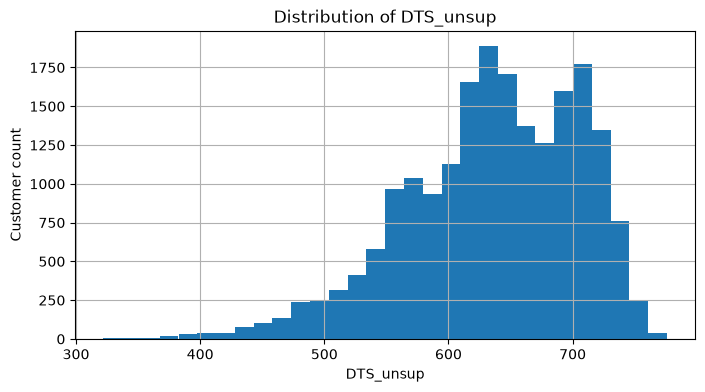

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(submission_unsup["DTS_unsup"], bins=30)
plt.xlabel("DTS_unsup")
plt.ylabel("Customer count")
plt.title("Distribution of DTS_unsup")
plt.grid(True)
plt.show()

In [10]:
submission_unsup[["AnomalyScore", "DTS_unsup"]].corr(method="spearman")

,AnomalyScore,DTS_unsup
AnomalyScore,1.000000,-0.277658
DTS_unsup,-0.277658,1.000000


In [11]:
extreme_cols = [
    "CustomerID",
    "AnomalyScore",
    "DTS_unsup",
    "device_score",
    "sim_score",
    "behavior_score",
    "identity_score",
    "device_risk",
    "sim_risk",
    "behavior_risk",
    "identity_risk",
]

score_output[extreme_cols].nsmallest(
    20,
    "DTS_unsup",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
16779,3339522,0.998718,322,147.806731,627.580000,325.670000,76.338462,0.852193,0.372420,0.674330,0.923662
13187,3267142,0.996842,324,147.806731,690.080000,259.402500,76.338462,0.852193,0.309920,0.740598,0.923662
10989,3221866,0.902772,325,592.871154,136.311667,481.680625,76.338462,0.407129,0.863688,0.518319,0.923662
15910,3322122,0.994762,325,380.284615,488.736667,271.025000,76.338462,0.619715,0.511263,0.728975,0.923662
687,3013406,0.997530,331,321.046154,535.588333,300.896875,76.338462,0.678954,0.464412,0.699103,0.923662
129,3002898,0.941473,332,770.619231,188.365000,271.308125,76.338462,0.229381,0.811635,0.728692,0.923662
15815,3320222,0.994085,332,320.717308,457.806667,398.545000,76.338462,0.679283,0.542193,0.601455,0.923662
15561,3314990,0.938975,337,866.501923,122.273333,273.791875,76.338462,0.133498,0.877727,0.726208,0.923662
9241,3186290,0.997200,338,320.780769,506.258333,360.980625,76.338462,0.679219,0.493742,0.639019,0.923662
584,3011570,0.999942,339,147.806731,739.028333,259.184375,76.338462,0.852193,0.260972,0.740816,0.923662


In [12]:
score_output[extreme_cols].nlargest(
    20,
    "DTS_unsup",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
8503,3171402,0.147673,776,866.501923,708.796667,653.291875,917.788462,0.133498,0.291203,0.346708,0.082212
102,3002354,0.906868,775,866.501923,740.068333,609.610000,917.788462,0.133498,0.259932,0.390390,0.082212
1782,3035742,0.798913,774,866.501923,733.543333,627.440000,904.271154,0.133498,0.266457,0.372560,0.095729
6553,3132182,0.413038,772,866.501923,721.678333,647.586875,885.521154,0.133498,0.278322,0.352413,0.114479
19549,3390802,0.435538,770,866.501923,730.570000,602.750000,917.788462,0.133498,0.269430,0.397250,0.082212
3459,3070194,0.825642,768,866.501923,721.678333,617.216250,902.903846,0.133498,0.278322,0.382784,0.097096
4667,3094330,0.361692,768,866.501923,725.393333,602.219375,917.788462,0.133498,0.274607,0.397781,0.082212
10834,3218638,0.217963,767,866.501923,706.416667,648.614375,882.498077,0.133498,0.293583,0.351386,0.117502
19708,3393638,0.120087,767,866.501923,735.876667,614.002500,879.625000,0.133498,0.264123,0.385997,0.120375
3203,3064394,0.350960,766,866.501923,727.075000,589.291250,917.788462,0.133498,0.272925,0.410709,0.082212


In [13]:
score_output[extreme_cols].nlargest(
    20,
    "AnomalyScore",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
584,3011570,0.999942,339,147.806731,739.028333,259.184375,76.338462,0.852193,0.260972,0.740816,0.923662
2593,3052314,0.999935,405,147.806731,729.440000,362.746250,295.117308,0.852193,0.270560,0.637254,0.704883
5059,3101590,0.999692,416,380.078846,715.510000,363.863750,76.338462,0.619921,0.284490,0.636136,0.923662
4795,3096614,0.999633,448,380.078846,661.633333,353.755000,332.721154,0.619921,0.338367,0.646245,0.667279
1760,3035234,0.999452,468,380.078846,731.566667,376.593750,296.005769,0.619921,0.268433,0.623406,0.703994
19942,3398714,0.999305,351,147.806731,734.410000,311.930625,76.338462,0.852193,0.265590,0.688069,0.923662
4256,3086598,0.999290,349,380.284615,515.536667,47.918750,435.171154,0.619715,0.484463,0.952081,0.564829
14556,3295838,0.999235,400,321.046154,694.246667,383.568125,76.338462,0.678954,0.305753,0.616432,0.923662
14335,3291262,0.999180,432,380.150000,686.195000,226.899375,374.248077,0.619850,0.313805,0.773101,0.625752
9118,3183658,0.999152,410,380.150000,701.116667,358.858125,76.338462,0.619850,0.298883,0.641142,0.923662


In [14]:
score_output[
    (score_output["AnomalyScore"] >= score_output["AnomalyScore"].quantile(0.96))
    & (score_output["DTS_unsup"] >= score_output["DTS_unsup"].quantile(0.75))
][extreme_cols].sort_values("AnomalyScore", ascending=False).head(20)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
10376,3209150,0.986535,697,789.073077,701.116667,550.741250,759.959615,0.210927,0.298883,0.449259,0.240040
5507,3111026,0.984025,696,693.190385,713.246667,547.750625,856.559615,0.306810,0.286753,0.452249,0.143440
286,3005526,0.974845,697,694.938462,739.743333,653.291875,689.332692,0.305062,0.260257,0.346708,0.310667
486,3009646,0.972500,722,790.821154,738.626667,582.483750,784.715385,0.209179,0.261373,0.417516,0.215285
17435,3353246,0.961585,695,693.190385,686.195000,568.154375,866.603846,0.306810,0.313805,0.431846,0.133396
335,3006534,0.956440,698,693.190385,738.848333,614.381875,749.759615,0.306810,0.261152,0.385618,0.250240
19769,3395318,0.952910,695,770.619231,737.113333,431.730625,867.134615,0.229381,0.262887,0.568269,0.132865
5349,3107810,0.951760,712,789.073077,715.510000,516.016250,854.009615,0.210927,0.284490,0.483984,0.145990
5974,3120966,0.949623,733,789.073077,721.678333,653.291875,780.440385,0.210927,0.278322,0.346708,0.219560
16357,3330830,0.944913,697,866.501923,690.080000,433.150625,826.028846,0.133498,0.309920,0.566849,0.173971


In [15]:
score_output[
    (score_output["DTS_unsup"] <= score_output["DTS_unsup"].quantile(0.10))
    & (score_output["AnomalyScore"] <= score_output["AnomalyScore"].quantile(0.50))
][extreme_cols].sort_values("DTS_unsup").head(20)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
9486,3190998,0.262332,389,770.619231,154.068333,540.721875,76.338462,0.229381,0.845932,0.459278,0.923662
12515,3253398,0.450522,393,770.619231,150.653333,559.844375,76.338462,0.229381,0.849347,0.440156,0.923662
18641,3375078,0.395128,396,770.619231,125.791667,602.750000,76.338462,0.229381,0.874208,0.397250,0.923662
10317,3207730,0.266338,417,770.619231,72.806667,498.961250,388.809615,0.229381,0.927193,0.501039,0.611190
9542,3192250,0.428968,418,866.501923,152.828333,561.910000,76.338462,0.133498,0.847172,0.438090,0.923662
15100,3305734,0.485127,422,866.501923,142.471667,587.824375,76.338462,0.133498,0.857528,0.412176,0.923662
12326,3249734,0.366553,432,770.619231,110.063333,511.402500,394.180769,0.229381,0.889937,0.488598,0.605819
13147,3266302,0.417087,436,770.619231,331.665000,515.170625,76.338462,0.229381,0.668335,0.484829,0.923662
7497,3151654,0.303102,436,770.619231,100.818333,538.465000,394.180769,0.229381,0.899182,0.461535,0.605819
10574,3213262,0.471042,437,770.619231,149.733333,548.899375,309.315385,0.229381,0.850267,0.451101,0.690685


In [16]:
submission_unsup.to_csv(
    OUTPUT_DIR / "trackA_holdout_submission.csv",
    index=False,
)

score_output.to_csv(
    OUTPUT_DIR / "dts_unsup_with_pillars.csv",
    index=False,
)

print("Saved:")
print(OUTPUT_DIR / "trackA_holdout_submission.csv")
print(OUTPUT_DIR / "dts_unsup_with_pillars.csv")

Saved:
../outputs/trackA_holdout_submission.csv
../outputs/dts_unsup_with_pillars.csv
